In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as ticker
import os
import scipy.stats as stats

In [4]:
# Load optimized parameters from EA
activator_df = pd.read_csv('../Parameters_for_activator_inhibition.csv')
spen_df = pd.read_csv('../Parameters_for_SPEN_depletion.csv')
activator_df.drop(activator_df.columns[0], axis=1, inplace=True)
spen_df.drop(spen_df.columns[0], axis=1, inplace=True)

# Drop the first column from both DataFrames
activator_df.drop(activator_df.columns[0], axis=1, inplace=True)
spen_df.drop(spen_df.columns[0], axis=1, inplace=True)
activator_df["Kd"] = activator_df['k4']/activator_df['k3']
spen_df["Kd"] = spen_df['k4']/spen_df['k3']

In [5]:
# Dictionary to store results
ks_results = {}

# Compare each column using the KS test
for column in activator_df.columns:
    # Drop NA values in case there are any missing values
    data1 = activator_df[column].dropna()
    data2 = spen_df[column].dropna()
    
    # Perform the two-sample KS test
    stat, p_value = stats.ks_2samp(data1, data2)
    ks_results[column] = {'KS statistic': stat, 'p-value': p_value}

# Print the results
for col, result in ks_results.items():
    print(f"Column: {col}\n\tKS statistic: {result['KS statistic']:.4f}, p-value: {result['p-value']:.4f}")


Column: d_act
	KS statistic: 0.1835, p-value: 0.2620
Column: K_n
	KS statistic: 0.2842, p-value: 0.0165
Column: n
	KS statistic: 0.1725, p-value: 0.3289
Column: a_x
	KS statistic: 0.1273, p-value: 0.6984
Column: d_x
	KS statistic: 0.1350, p-value: 0.6287
Column: m
	KS statistic: 0.2997, p-value: 0.0097
Column: K_S
	KS statistic: 0.6673, p-value: 0.0000
Column: K_a
	KS statistic: 0.1163, p-value: 0.7931
Column: k1
	KS statistic: 0.2235, p-value: 0.1009
Column: k2
	KS statistic: 0.1273, p-value: 0.6984
Column: k4
	KS statistic: 0.7661, p-value: 0.0000
Column: k3
	KS statistic: 0.8559, p-value: 0.0000
Column: XbsT
	KS statistic: 0.1376, p-value: 0.6050
Column: sT
	KS statistic: 0.2145, p-value: 0.1273
Column: Kd
	KS statistic: 0.8779, p-value: 0.0000


In [7]:
def significance_stars(p):
    if p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return ""

In [8]:
def format_func(value, tick_number):
    exponent = np.log10(value)
    if exponent.is_integer():
        return f'$10^{{{int(exponent)}}}$'
    else:
        return f'$10^{{{exponent:.1f}}}$'

/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_62883/2522818598.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=data, showfliers=False, palette='pastel')


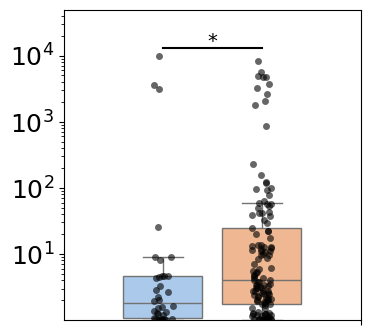

/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_62883/2522818598.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=data, showfliers=False, palette='pastel')


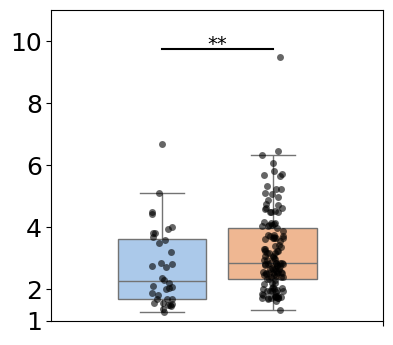

/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_62883/2522818598.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=data, showfliers=False, palette='pastel')


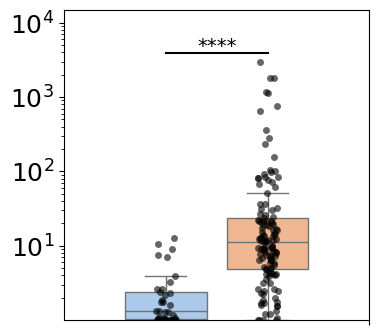

/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_62883/2522818598.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=data, showfliers=False, palette='pastel')


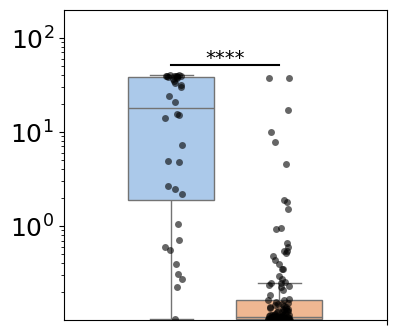

/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_62883/2522818598.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=data, showfliers=False, palette='pastel')


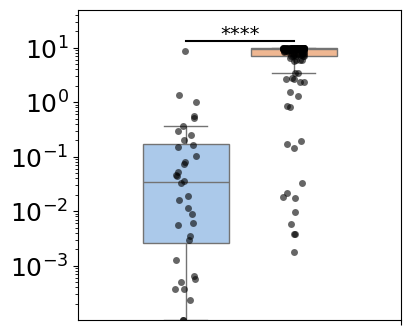

/var/folders/x7/mfl8dc6n5wb0940l446q76w80000gn/T/ipykernel_62883/2522818598.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=data, showfliers=False, palette='pastel')


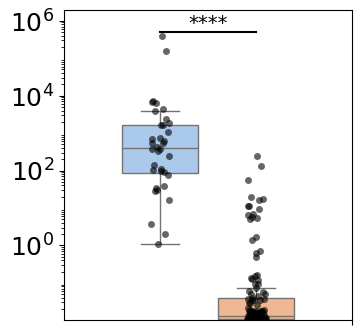

In [10]:
# Identify columns with p-value < 0.05
significant_columns = [col for col, res in ks_results.items() if res['p-value'] < 0.05]

# Plot for each significant column
for col in significant_columns:
    # Create a combined DataFrame for plotting
    data = pd.DataFrame({
        'Value': pd.concat([activator_df[col].dropna(), spen_df[col].dropna()]),
        'Group': (['Activator \ninhibition'] * len(activator_df[col].dropna()) + 
                  ['SPEN \ndepletion'] * len(spen_df[col].dropna()))
    })
    p_val = ks_results[col]['p-value']
    stars = significance_stars(p_val)
    y_min = data['Value'].min()
    y_max = data['Value'].max()
    y_offset = y_max * 0.005  # 5% above the max value
    # Annotate the significance stars at the horizontal center (x=0.5 between boxes)
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.boxplot(x='Group', y='Value', data=data, showfliers=False, palette='pastel')
    sns.stripplot(x='Group', y='Value', data=data, color='black', alpha=0.6)
    #plt.title(f"{col}")
    plt.tight_layout()

    # Set the major ticks locator to place ticks at powers of 10
    # Apply the formatter to the y-axis
    tick_positions = np.logspace(-4, 4, num=17)
    ax.set_yticks(tick_positions)
    
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

    plt.xlim([-1,1])
    plt.tick_params(axis='both', which='major', labelsize=13)
    plt.xlabel('')
    plt.xticks('')
    plt.ylabel('')
    if col == "m":
        plt.yscale('linear')
        plt.ylim([y_min,y_max+y_offset*20])
        plt.text(0.5, y_max+y_offset*2, stars, ha='center', va='bottom',
            color='k', fontsize=14)
        plt.plot([0,1],[y_max+y_offset*5,y_max+y_offset*5],'k')
        plt.ylim([1,11])
        plt.yticks([1,2,4,6,8,10])
    else:
        plt.yscale('log')
        plt.ylim([y_min,y_max+800*y_offset])
        plt.text(0.5, y_max+40*y_offset, stars, ha='center', va='bottom',
            color='k', fontsize=14)
        plt.plot([0,1],[y_max+60*y_offset,y_max+60*y_offset],'k')
    if col == "Kd":
        plt.yticks([1,100,10000,10**6])
    plt.xticks(fontsize=18) 
    plt.yticks(fontsize=18)
    plt.savefig(col+'_p_values.png',bbox_inches='tight',dpi=300)


    plt.show()